# Prophet for Time Series

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from tools.metrics import measuring_predictions, model_assessment
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

from prophet.utilities import regressor_coefficients
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric

from sklearn.model_selection import ParameterGrid

from statsmodels.graphics.tsaplots import month_plot
from statsmodels.tsa.seasonal import seasonal_decompose
from datetime import datetime
import holidays


c:\development\time_series_course\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
df = pd.read_csv("./data/Daily Bike Sharing training.csv")
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,1/1/2011,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,1/2/2011,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,1/3/2011,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,1/4/2011,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,1/5/2011,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [3]:
df["dteday"] = pd.to_datetime(df["dteday"], format="%m/%d/%Y")

In [4]:
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 701 entries, 0 to 700
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     701 non-null    int64         
 1   dteday      701 non-null    datetime64[us]
 2   season      701 non-null    int64         
 3   yr          701 non-null    int64         
 4   mnth        701 non-null    int64         
 5   holiday     701 non-null    int64         
 6   weekday     701 non-null    int64         
 7   workingday  701 non-null    int64         
 8   weathersit  701 non-null    int64         
 9   temp        701 non-null    float64       
 10  atemp       701 non-null    float64       
 11  hum         701 non-null    float64       
 12  windspeed   701 non-null    float64       
 13  casual      701 non-null    int64         
 14  registered  701 non-null    int64         
 15  cnt         701 non-null    int64         
dtypes: datetime64[us](1), float64(4), int

In [6]:
df = df.rename(columns={"cnt": "y", "dteday": "ds"})

In [7]:
df.head()

,instant,ds,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,y
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [8]:
df = df.drop(["instant", "season", "yr", "mnth", "weekday", "casual", "registered"], axis=1)

In [9]:
# Preparing Wheater Situation
df = pd.get_dummies(df, columns=["workingday", "holiday", "weathersit"], drop_first=True, dtype=int)
df.head()

,ds,temp,atemp,hum,windspeed,y,workingday_1,holiday_1,weathersit_2,weathersit_3
0,2011-01-01,0.344167,0.363625,0.805833,0.160446,985,0,0,1,0
1,2011-01-02,0.363478,0.353739,0.696087,0.248539,801,0,0,1,0
2,2011-01-03,0.196364,0.189405,0.437273,0.248309,1349,1,0,0,0
3,2011-01-04,0.200000,0.212122,0.590435,0.160296,1562,1,0,0,0
4,2011-01-05,0.226957,0.229270,0.436957,0.186900,1600,1,0,0,0


### Exploratory data analysis

In [10]:
plot_df = df.set_index("ds")

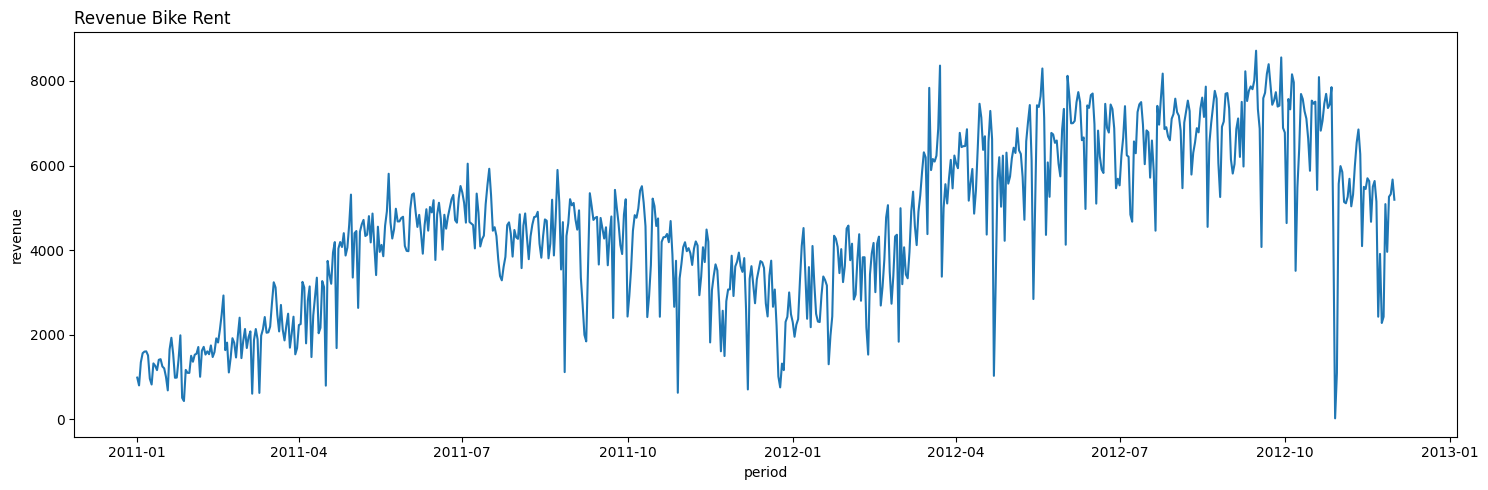

In [11]:
plt.figure(figsize=(15, 5))
plt.plot(plot_df["y"])
plt.title("Revenue Bike Rent", loc="left")
plt.xlabel("period")
plt.ylabel("revenue")
plt.tight_layout()
plt.show()

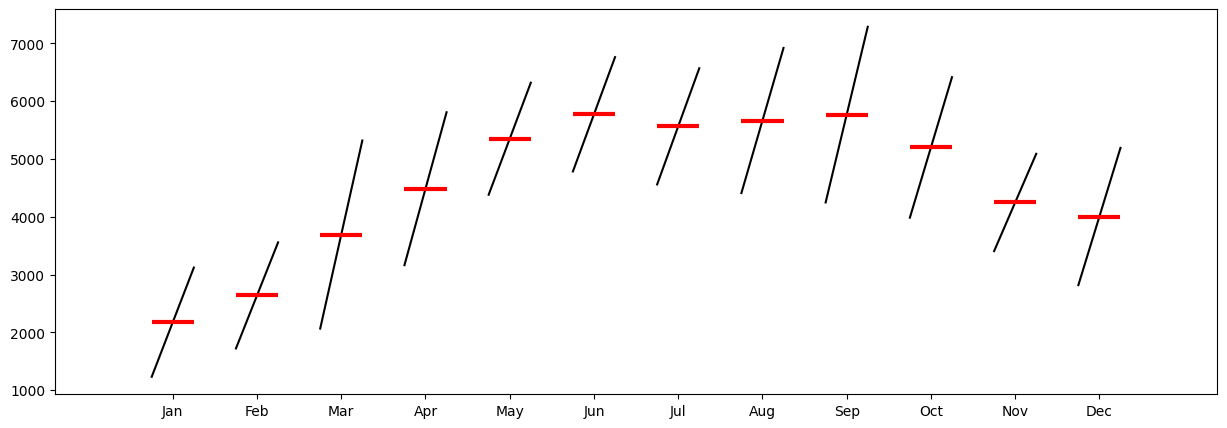

In [12]:
fig, ax = plt.subplots(figsize=(15, 5))
month_plot(plot_df["y"].resample("ME").mean(), ax=ax)
plt.show()

C:\Users\Vinicius\AppData\Local\Temp\ipykernel_17236\1960092612.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


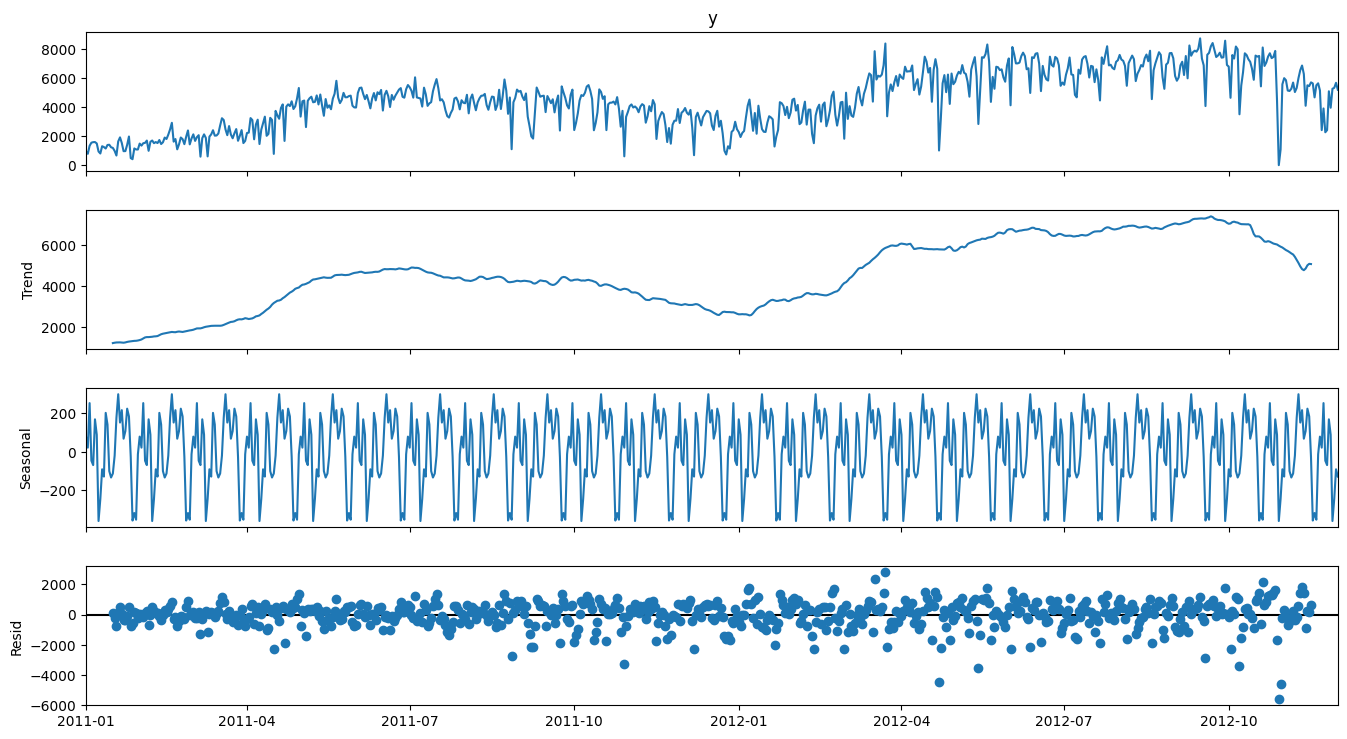

In [13]:
decomposition = seasonal_decompose(
    x=plot_df["y"], model="additive", period=30
)

fig = decomposition.plot()
fig.set_size_inches((15, 8))
fig.show()

#### Checking Holidays

In [14]:
us_holidays = holidays.US(state='DC')

holidays = df.loc[df["holiday_1"]==1, ["ds"]].reset_index(drop=True)
holidays["lower_window"] = -2
holidays["upper_window"] = 2
holidays["holiday"] = holidays["ds"].apply(lambda x: us_holidays[x])

_years = holidays["ds"].dt.year.unique()

# Adding Christmas
christmas_and_new_year = pd.DataFrame(data={
    "ds": [datetime(y, 12, d) for y in _years for d in [24, 31]],
    "lower_window": -3, 
    "upper_window": 3, 
    "holiday": ["Christmas", "New Year", "Christmas", "New Year"]
})

holidays = pd.concat([holidays, christmas_and_new_year], axis=0).reset_index(drop=True)
holidays

,ds,lower_window,upper_window,holiday
0,2011-01-17,-2,2,Martin Luther King Jr. Day
1,2011-02-21,-2,2,Washington's Birthday
2,2011-04-15,-2,2,Emancipation Day (observed)
3,2011-05-30,-2,2,Memorial Day
4,2011-07-04,-2,2,Independence Day
5,2011-09-05,-2,2,Labor Day
6,2011-10-10,-2,2,Columbus Day
7,2011-11-11,-2,2,Veterans Day
8,2011-11-24,-2,2,Thanksgiving Day
9,2011-12-26,-2,2,Christmas Day (observed)


### Feature Engineering

In [15]:
# Creating lags for some regressors

lags = [1, 3, 5, 7]
for lag in lags:
    df[f"temp_lag_{lag}"] = df["temp"].shift(lag)
    df[f"atemp_lag_{lag}"] = df["atemp"].shift(lag)

In [16]:
df.head()

,ds,temp,atemp,hum,windspeed,y,workingday_1,holiday_1,weathersit_2,weathersit_3,temp_lag_1,atemp_lag_1,temp_lag_3,atemp_lag_3,temp_lag_5,atemp_lag_5,temp_lag_7,atemp_lag_7
0,2011-01-01,0.344167,0.363625,0.805833,0.160446,985,0,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2011-01-02,0.363478,0.353739,0.696087,0.248539,801,0,0,1,0,0.344167,0.363625,NaN,NaN,NaN,NaN,NaN,NaN
2,2011-01-03,0.196364,0.189405,0.437273,0.248309,1349,1,0,0,0,0.363478,0.353739,NaN,NaN,NaN,NaN,NaN,NaN
3,2011-01-04,0.200000,0.212122,0.590435,0.160296,1562,1,0,0,0,0.196364,0.189405,0.344167,0.363625,NaN,NaN,NaN,NaN
4,2011-01-05,0.226957,0.229270,0.436957,0.186900,1600,1,0,0,0,0.200000,0.212122,0.363478,0.353739,NaN,NaN,NaN,NaN


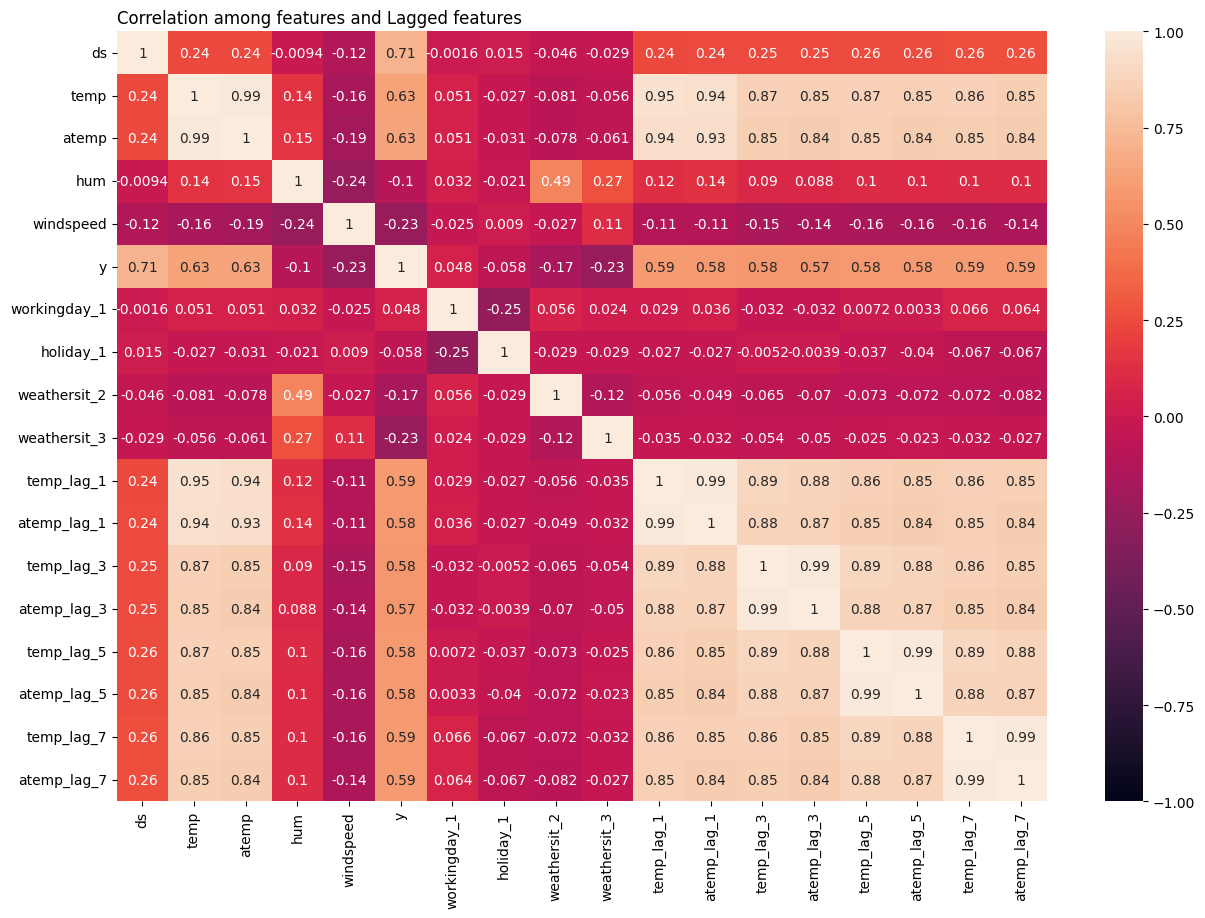

In [17]:
corr_matrix = df.corr()

import seaborn as sns

plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, vmax=1, vmin=-1, annot=True)
plt.title("Correlation among features and Lagged features", loc="left")
plt.show()

Correlation between lagged values of Revenue (y) are moderate and might not be relevante for our modeling

## Building model

In [18]:
X_train = df.iloc[:-30]
X_test = df.iloc[-30:]

y_train = X_train["y"]
y_test = X_test["y"]

In [19]:
m = Prophet(
    weekly_seasonality=True,
    holidays=holidays,
    holidays_prior_scale=10,
    seasonality_mode="additive",
    seasonality_prior_scale=10,
    changepoint_prior_scale=0.05
)

regressors = X_train.columns.drop(["ds", "y"])

m.add_regressor(regressors[0])
m.add_regressor(regressors[1])
m.add_regressor(regressors[2])
m.add_regressor(regressors[3])
m.add_regressor(regressors[4])
m.add_regressor(regressors[5])
m.add_regressor(regressors[6])
m.add_regressor(regressors[7])

m.fit(X_train)

11:19:38 - cmdstanpy - INFO - Chain [1] start processing
11:19:38 - cmdstanpy - INFO - Chain [1] done processing


In [20]:
# Regressor Coefficients

regressor_coefficients(m)

,regressor,regressor_mode,center,coef_lower,coef,coef_upper
0,temp,additive,0.510283,1964.308550,1964.308550,1964.308550
1,atemp,additive,0.487429,2557.240232,2557.240232,2557.240232
2,hum,additive,0.627674,-1308.701372,-1308.701372,-1308.701372
3,windspeed,additive,0.190853,-2455.184215,-2455.184215,-2455.184215
4,workingday_1,additive,0.000000,659.749201,659.749201,659.749201
5,holiday_1,additive,0.000000,82.588647,82.588647,82.588647
6,weathersit_2,additive,0.000000,-423.671255,-423.671255,-423.671255
7,weathersit_3,additive,0.000000,-2117.796098,-2117.796098,-2117.796098


In [21]:
def interpreting_model(df: pd.DataFrame):
    results = []
    
    for _, row in df.iterrows():
        regressor = row["regressor"]
        mode = row["regressor_mode"]
        coef = row["coef"]
        center = row.get("center", 0)

        direction = "increases" if coef > 0 else "decreases"
        abs_coef = abs(coef)

        if mode == "additive":
            interpretation = (
                f"For each 1 unit increase in '{regressor}' "
                f"(relative to its centered value {center}), "
                f"the forecast {direction} by approximately {abs_coef:.2f} units."
            )

        elif mode == "multiplicative":
            interpretation = (
                f"For each 1 unit increase in '{regressor}' "
                f"(relative to its centered value {center}), "
                f"the forecast {direction} proportionally "
                f"by a factor of {abs_coef:.4f} (multiplicative effect)."
            )

        else:
            interpretation = (
                f"Regressor '{regressor}' has an unrecognized mode: '{mode}'."
            )

        results.append(interpretation)

    return results

In [22]:
interpreting_model(regressor_coefficients(m))

["For each 1 unit increase in 'temp' (relative to its centered value 0.5102828619970193), the forecast increases by approximately 1964.31 units.",
 "For each 1 unit increase in 'atemp' (relative to its centered value 0.48742947943368115), the forecast increases by approximately 2557.24 units.",
 "For each 1 unit increase in 'hum' (relative to its centered value 0.6276737555886736), the forecast decreases by approximately 1308.70 units.",
 "For each 1 unit increase in 'windspeed' (relative to its centered value 0.19085326915052164), the forecast decreases by approximately 2455.18 units.",
 "For each 1 unit increase in 'workingday_1' (relative to its centered value 0.0), the forecast increases by approximately 659.75 units.",
 "For each 1 unit increase in 'holiday_1' (relative to its centered value 0.0), the forecast increases by approximately 82.59 units.",
 "For each 1 unit increase in 'weathersit_2' (relative to its centered value 0.0), the forecast decreases by approximately 423.67 u

## Cross-Validation

In [23]:
cross_val_data = cross_validation(
    model=m, 
    horizon="30 days", 
    period="15 days", 
    initial=f"{df.shape[0] - 180} days", 
    parallel="processes"
)

cross_val_data.head(15)

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2012-06-20,7936.696899,7109.294668,8685.487766,6211,2012-06-19
1,2012-06-21,8249.791215,7438.674154,9065.144165,5905,2012-06-19
2,2012-06-22,7982.307652,7165.011388,8774.373591,5823,2012-06-19
3,2012-06-23,7740.315436,6898.606654,8517.154005,7458,2012-06-19
4,2012-06-24,7648.478104,6851.497052,8449.622578,6891,2012-06-19
5,2012-06-25,7193.232755,6444.814358,7993.247026,6779,2012-06-19
6,2012-06-26,7133.962267,6288.055904,7902.301774,7442,2012-06-19
7,2012-06-27,7513.982800,6647.126249,8356.365665,7335,2012-06-19
8,2012-06-28,7995.463993,7206.825678,8808.958632,6879,2012-06-19
9,2012-06-29,8507.684712,7710.155032,9300.478308,5463,2012-06-19


In [24]:
performance = performance_metrics(cross_val_data)
performance["accuracy"] = 1 - performance["mape"]
performance

,horizon,mse,rmse,mae,mape,mdape,smape,coverage,accuracy
0,3 days,1.810588e+06,1345.580923,1026.851473,0.180598,0.098244,0.156445,0.541667,0.819402
1,4 days,1.772243e+06,1331.256208,914.039744,0.156062,0.076618,0.134087,0.625000,0.843938
2,5 days,1.943336e+06,1394.035986,901.823988,0.167621,0.062398,0.137001,0.708333,0.832379
3,6 days,1.351492e+06,1162.536858,762.149793,0.137658,0.058368,0.116362,0.791667,0.862342
4,7 days,1.065889e+06,1032.419197,729.016498,0.124233,0.069474,0.110434,0.791667,0.875767
5,8 days,5.093969e+05,713.720450,595.227310,0.086247,0.076117,0.086695,0.833333,0.913753
6,9 days,4.717432e+05,686.835642,573.008600,0.082088,0.078996,0.082042,0.833333,0.917912
7,10 days,7.185895e+05,847.696564,615.436060,0.092557,0.069711,0.087362,0.833333,0.907443
8,11 days,9.379258e+05,968.465684,692.025963,0.106238,0.075472,0.097785,0.791667,0.893762
9,12 days,1.208638e+06,1099.380668,750.366853,0.116615,0.059584,0.106052,0.708333,0.883385


In [25]:
performance.mean()

horizon     16 days 12:00:00
mse           1339272.249438
rmse             1127.340281
mae               826.551831
mape                 1.00169
mdape               0.081955
smape               0.130234
coverage            0.706845
accuracy            -0.00169
dtype: object

### Parameters Tunning

In [26]:
param_grid = {
    "changepoint_prior_scale": [0.05, 0.5],
    "seasonality_prior_scale": [10, 20],
    "holidays_prior_scale": [10, 20],
    "seasonality_mode": ["additive", "multiplicative"],
}

all_params = list(ParameterGrid(param_grid))
all_params

[{'changepoint_prior_scale': 0.05,
  'holidays_prior_scale': 10,
  'seasonality_mode': 'additive',
  'seasonality_prior_scale': 10},
 {'changepoint_prior_scale': 0.05,
  'holidays_prior_scale': 10,
  'seasonality_mode': 'additive',
  'seasonality_prior_scale': 20},
 {'changepoint_prior_scale': 0.05,
  'holidays_prior_scale': 10,
  'seasonality_mode': 'multiplicative',
  'seasonality_prior_scale': 10},
 {'changepoint_prior_scale': 0.05,
  'holidays_prior_scale': 10,
  'seasonality_mode': 'multiplicative',
  'seasonality_prior_scale': 20},
 {'changepoint_prior_scale': 0.05,
  'holidays_prior_scale': 20,
  'seasonality_mode': 'additive',
  'seasonality_prior_scale': 10},
 {'changepoint_prior_scale': 0.05,
  'holidays_prior_scale': 20,
  'seasonality_mode': 'additive',
  'seasonality_prior_scale': 20},
 {'changepoint_prior_scale': 0.05,
  'holidays_prior_scale': 20,
  'seasonality_mode': 'multiplicative',
  'seasonality_prior_scale': 10},
 {'changepoint_prior_scale': 0.05,
  'holidays_prio

In [27]:
regressors = X_train.columns.drop(["ds", "y"])

tunning_results = []
for params in all_params:

    # Building the model
    m = Prophet(
        weekly_seasonality=True,
        holidays=holidays,
        **params,
    )

    m.add_regressor(regressors[0])
    m.add_regressor(regressors[1])
    m.add_regressor(regressors[2])
    m.add_regressor(regressors[3])
    m.add_regressor(regressors[4])
    m.add_regressor(regressors[5])
    m.add_regressor(regressors[6])
    m.add_regressor(regressors[7])

    m.fit(X_train)

    # Cross-validation
    cross_val_df = cross_validation(
        model=m,
        horizon="30 days", 
        period="15 days", 
        initial=f"{X_train.shape[0] - 180} days", 
        parallel="processes"
    )

    # Compute and store the error
    rmse = performance_metrics(df=cross_val_df)["rmse"].mean()
    tunning_results.append(rmse)

11:19:40 - cmdstanpy - INFO - Chain [1] start processing
11:19:40 - cmdstanpy - INFO - Chain [1] done processing
11:19:42 - cmdstanpy - INFO - Chain [1] start processing
11:19:42 - cmdstanpy - INFO - Chain [1] done processing
11:19:44 - cmdstanpy - INFO - Chain [1] start processing
11:19:44 - cmdstanpy - INFO - Chain [1] done processing
11:19:46 - cmdstanpy - INFO - Chain [1] start processing
11:19:46 - cmdstanpy - INFO - Chain [1] done processing
11:19:48 - cmdstanpy - INFO - Chain [1] start processing
11:19:48 - cmdstanpy - INFO - Chain [1] done processing
11:19:50 - cmdstanpy - INFO - Chain [1] start processing
11:19:50 - cmdstanpy - INFO - Chain [1] done processing
11:19:51 - cmdstanpy - INFO - Chain [1] start processing
11:19:52 - cmdstanpy - INFO - Chain [1] done processing
11:19:54 - cmdstanpy - INFO - Chain [1] start processing
11:19:54 - cmdstanpy - INFO - Chain [1] done processing
11:19:56 - cmdstanpy - INFO - Chain [1] start processing
11:19:56 - cmdstanpy - INFO - Chain [1]

In [28]:
outcome = pd.DataFrame(all_params)
outcome["tunning_params"] = tunning_results
outcome = outcome.sort_values(by="tunning_params").reset_index(drop=True)
outcome

,changepoint_prior_scale,holidays_prior_scale,seasonality_mode,seasonality_prior_scale,tunning_params
0,0.05,20,additive,20,1124.282683
1,0.05,10,additive,20,1125.091098
2,0.05,10,additive,10,1127.589605
3,0.05,20,additive,10,1127.955969
4,0.50,10,additive,20,1196.940989
5,0.50,20,additive,10,1197.248988
6,0.50,20,additive,20,1197.907794
7,0.50,10,additive,10,1198.227320
8,0.50,20,multiplicative,10,1321.657992
9,0.50,10,multiplicative,10,1323.633182


In [29]:
best_params = outcome.loc[0].drop(["tunning_params"]).to_dict()

### Predicting the Future

### Future regressors

In [36]:
future_regressors = df.loc[:, regressors].reset_index(drop=True)
future_regressors.head()

,temp,atemp,hum,windspeed,workingday_1,holiday_1,weathersit_2,weathersit_3,temp_lag_1,atemp_lag_1,temp_lag_3,atemp_lag_3,temp_lag_5,atemp_lag_5,temp_lag_7,atemp_lag_7
0,0.344167,0.363625,0.805833,0.160446,0,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.363478,0.353739,0.696087,0.248539,0,0,1,0,0.344167,0.363625,NaN,NaN,NaN,NaN,NaN,NaN
2,0.196364,0.189405,0.437273,0.248309,1,0,0,0,0.363478,0.353739,NaN,NaN,NaN,NaN,NaN,NaN
3,0.200000,0.212122,0.590435,0.160296,1,0,0,0,0.196364,0.189405,0.344167,0.363625,NaN,NaN,NaN,NaN
4,0.226957,0.229270,0.436957,0.186900,1,0,0,0,0.200000,0.212122,0.363478,0.353739,NaN,NaN,NaN,NaN


In [38]:
future = m.make_future_dataframe(periods=30, freq="D")
future = pd.concat([future, future_regressors], axis=1).dropna()
future

,ds,temp,atemp,hum,windspeed,workingday_1,holiday_1,weathersit_2,weathersit_3,temp_lag_1,atemp_lag_1,temp_lag_3,atemp_lag_3,temp_lag_5,atemp_lag_5,temp_lag_7,atemp_lag_7
7,2011-01-08,0.165000,0.162254,0.535833,0.266804,0,0,1,0,0.196522,0.208839,0.226957,0.229270,0.196364,0.189405,0.344167,0.363625
8,2011-01-09,0.138333,0.116175,0.434167,0.361950,0,0,0,0,0.165000,0.162254,0.204348,0.233209,0.200000,0.212122,0.363478,0.353739
9,2011-01-10,0.150833,0.150888,0.482917,0.223267,1,0,0,0,0.138333,0.116175,0.196522,0.208839,0.226957,0.229270,0.196364,0.189405
10,2011-01-11,0.169091,0.191464,0.686364,0.122132,1,0,1,0,0.150833,0.150888,0.165000,0.162254,0.204348,0.233209,0.200000,0.212122
11,2011-01-12,0.172727,0.160473,0.599545,0.304627,1,0,0,0,0.169091,0.191464,0.138333,0.116175,0.196522,0.208839,0.226957,0.229270
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
696,2012-11-27,0.291667,0.281558,0.786667,0.237562,1,0,1,0,0.313333,0.339004,0.278333,0.248742,0.340000,0.350371,0.374167,0.380667
697,2012-11-28,0.296667,0.289762,0.506250,0.210821,1,0,0,0,0.291667,0.281558,0.245833,0.257583,0.368333,0.378779,0.353333,0.364892
698,2012-11-29,0.280870,0.298422,0.555652,0.115522,1,0,0,0,0.296667,0.289762,0.313333,0.339004,0.278333,0.248742,0.340000,0.350371
699,2012-11-30,0.298333,0.323867,0.649583,0.058471,1,0,0,0,0.280870,0.298422,0.291667,0.281558,0.245833,0.257583,0.368333,0.378779


In [44]:
result = m.predict(future)
result["y"] = df["y"]
result.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,Christmas,Christmas_lower,Christmas_upper,Christmas Day (observed),...,windspeed_lower,windspeed_upper,workingday_1,workingday_1_lower,workingday_1_upper,additive_terms,additive_terms_lower,additive_terms_upper,yhat,y
689,2012-11-27,1791.573734,3973.729502,5702.825088,1695.976419,1868.724012,0.0,0.0,0.0,0.0,...,-0.118797,-0.118797,4.771103,4.771103,4.771103,0.0,0.0,0.0,4821.858595,5634
690,2012-11-28,1795.416936,5777.227131,7594.822149,1694.748097,1878.431058,0.0,0.0,0.0,0.0,...,-0.050785,-0.050785,4.771103,4.771103,4.771103,0.0,0.0,0.0,6693.751503,5146
691,2012-11-29,1799.260138,6152.520088,7959.514272,1692.089032,1888.412264,0.0,0.0,0.0,0.0,...,0.191595,0.191595,4.771103,4.771103,4.771103,0.0,0.0,0.0,7097.261802,2425
692,2012-11-30,1803.103340,6280.769243,8105.633881,1691.308554,1898.656983,0.0,0.0,0.0,0.0,...,0.336697,0.336697,4.771103,4.771103,4.771103,0.0,0.0,0.0,7208.847474,3910
693,2012-12-01,1806.946542,5226.638773,7049.824567,1689.330015,1913.428130,0.0,0.0,0.0,0.0,...,0.333560,0.333560,0.000000,0.000000,0.000000,0.0,0.0,0.0,6169.065534,2277
